# OMISH — gene biomarkers for weight-loss response

Reproducible record of every step. Each section explains what we do, why it applies to this cohort (n=89, p=13,519), the consequences, and the checkpoint decision. Code lives in `stepNN_*.py`; each section runs its script so the notebook and the scripts cannot diverge. Seeds are fixed. See `README.md` for the full plan and `DECISIONS.md` for the checkpoint log.

## Step 1 — Experiment design

**What we do.** Fix the rules of evidence before any model: positive class, cost of each error, primary metric, baselines, evaluation scheme.

**Why here.** With 13,519 genes and 89 samples, almost any method finds genes that separate the classes on the data it was fitted to. Deciding the rules first, and not changing them to fit the result, is the only defence.

**Decisions (see DECISIONS.md).**
- Positive class: Responders (54/89).
- Error costs, **revised 2026-09-17**: originally a spurious biomarker cost more than a missed one. The expert group reversed this: a missed Responder, and a missed real module, now cost more than a false alarm (screening logic: a false positive gets a second look, a false negative is lost). In practice: the classifier is reported at the operating point that catches 90% of Responders, with the specificity and precision that cost; stability selection tolerates 2 expected false selections instead of 1; every list is labelled as a screening list, not a confirmed set.
- Primary metric: ROC-AUC under repeated stratified CV (threshold-free ranking quality), with PR-AUC and, from the revision on, specificity and precision at 90% recall alongside. F1 at 0.5 is not used: with 61% Responders it scores a useless model at 0.75.
- Baselines: chance, and clinical-only (Age, Sex, COPD, Diabetes). A gene signature must beat clinical-only.
- Evaluation, **revised at step 4**: originally no hold-out split. The expert group asked for one, so 18 samples are set aside (step 4) and repeated stratified k-fold with every supervised step nested inside folds runs on the remaining 71.

**Consequences.** Unstable modules are reported as unstable. Under the revised error rule the candidate list is allowed to be longer and to contain a false positive by design; what it may not do is silently drop a module that is consistently, if weakly, selected. No claim of generalisation to other cohorts without external data.

In [1]:
%run step01_design.py

samples: 89   Responders: 54   Non_responders: 35
majority-class accuracy (chance baseline): 0.607
chance AUC: 0.500

Expected 95% CI width of an AUC estimate (true AUC 0.75):
  single 20% hold-out set (n=18): 0.47
  all samples via CV (n=89):      0.21

Clinical covariates vs label (potential confounders):
  Age    mean R=+0.09 NR=-0.15  t-test p=0.260  AUC=0.561
  Sex      rate R=0.44 NR=0.54  Fisher p=0.393  AUC=0.451
  COPD     rate R=0.41 NR=0.49  Fisher p=0.516  AUC=0.461
  Diabetes rate R=0.28 NR=0.26  Fisher p=1.000  AUC=0.510


## Step 2 — Exploratory data analysis

**What we do.** Look at the data before any model: per-sample expression distributions (normalisation), a sex-gene check against the Sex column (sample identity), PCA of all genes coloured by response and by each clinical covariate and by GEO series (batch), and an outlier scan. Everything here is unsupervised: the label is used only for colouring, never to change the data, so nothing leaks into later steps.

**Why here.** In a p >> n cohort the dominant sources of variance are usually technical (batch, array quality, sample swaps), not biology. If any of them align with the response label, a model will learn them and report them as biomarkers. PCA shows where the big variance is and whether it lines up with anything we know.

**How to read the PCA.** Each dot is one participant, placed by the two directions of largest expression variance. If Responders and Non-responders form separate clouds, the response signal is large and easy. If they overlap, the signal (if any) is small relative to other variance, and feature selection has to work harder. The same reading applies to Sex, COPD, Diabetes and batch: a covariate that separates on PC1 or PC2 is a confounder to control.

**Findings.**
- Arrays are on a common scale (per-sample medians 3.3–4.2); no re-normalisation needed.
- **Two GEO series are mixed: GSM1123xxx (63 samples) and GSM1616xxx (26 samples). They behave as two batches.** The GSM1616 samples spread along PC1 (SD 110 vs 24) and hardly at all along PC2 (SD 7 vs 39); the GSM1123 samples do the opposite. PC1 (28.5% of all variance) is therefore mostly batch, not biology.
- The sex-gene check confirms it: GSM1123 samples fall into clean female (high XIST) and male (high RPS4Y1) clusters and agree with the Sex column in 98% of cases. All 26 GSM1616 samples sit in a third, intermediate cluster where both genes are half-expressed. That pattern is not biological; it indicates a different platform, processing, or pooling for that series. The Sex column cannot be verified for those 26.
- One GSM1123 sample (GSM1123370) is labelled female but has a male expression profile: a probable sample or label swap.
- Batch is not associated with response (16/26 vs 38/63 responders), so it will not be learned as a proxy for the label. It will add noise and can hide real signal.
- No PC1–PC5 separates response, sex, COPD, diabetes or age. The response signal, if present, is small relative to the batch and other variance.

**Consequences.** Any gene ranking on the pooled 89 samples will be inflated by batch variance. Options for the checkpoint: (a) drop the 26 GSM1616 samples and work with 63 clean ones; (b) keep all 89 and correct for batch inside every CV fold (e.g. per-batch centring or a batch covariate in the model); (c) analyse per batch and require a gene to replicate in both. Sample GSM1123370 should be excluded or its label checked against GEO metadata.


**Update from GEO metadata (GSE66175, `GSE66175_samples.txt`).** All 89 samples are baseline arrays, one per participant, all from the intervention arm. The two GSM prefixes are two array batches of the same study, not different cohorts. Consequences: the question is "does baseline expression predict later response", which is the useful clinical framing; there are no repeated measures, so stratified CV over samples is valid; the batch correction stands. GSM1123370 is participant cv000777, baseline, labelled female, male expression profile, Responder.

In [2]:
%run step02_eda.py

per-sample median expression: min 3.31  max 4.17  (spread 0.85)
Sex==0: n=46  XIST mean=4.66  RPS4Y1 mean=4.09
Sex==1: n=43  XIST mean=1.71  RPS4Y1 mean=7.56
fraction agreeing with Sex column if 1=male: 0.89  (if 1=female: 0.11)
samples whose sex genes disagree with Sex column: ['GSM1123370', 'GSM1616283', 'GSM1616289', 'GSM1616295', 'GSM1616319', 'GSM1616325', 'GSM1616331', 'GSM1616343', 'GSM1616349', 'GSM1616377']
variance explained by PC1..PC5: 28.5%, 8.0%, 5.0%, 3.7%, 3.0%

PC vs variable (AUC for binary, |Spearman r| for Age); values near 0.5 / 0 mean no relation:
       Response       Sex      COPD  Diabetes       Age
PC1        0.56      0.54      0.58      0.58      0.02
PC2        0.59      0.50      0.60      0.60      0.12
PC3        0.61      0.50      0.53      0.57      0.03
PC4        0.53      0.55      0.60      0.51      0.14
PC5        0.57      0.57      0.51      0.61      0.00

GEO series prefix as batch: GSM1123=63  GSM1616=26
batch x response:
Responder   0   1


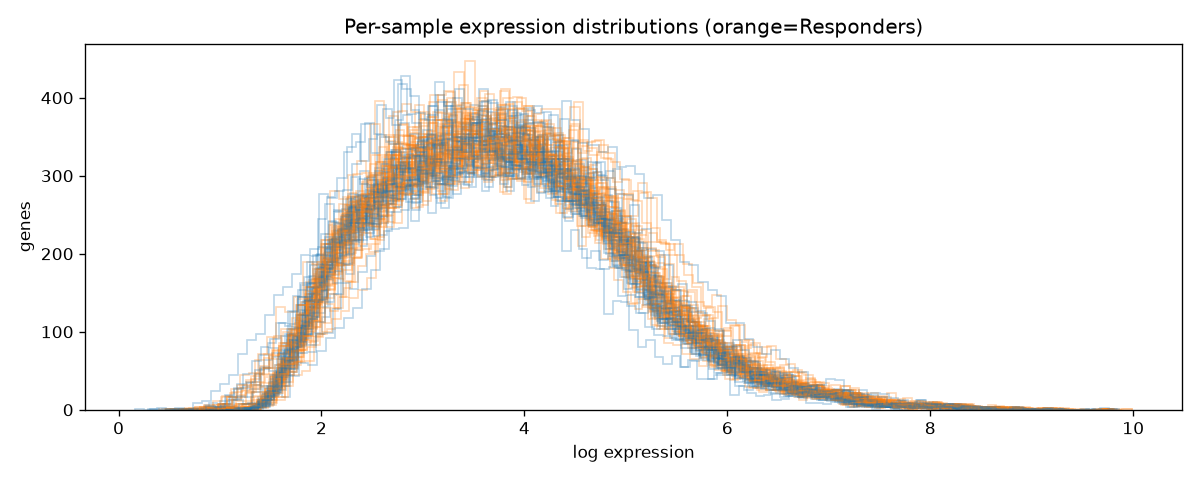

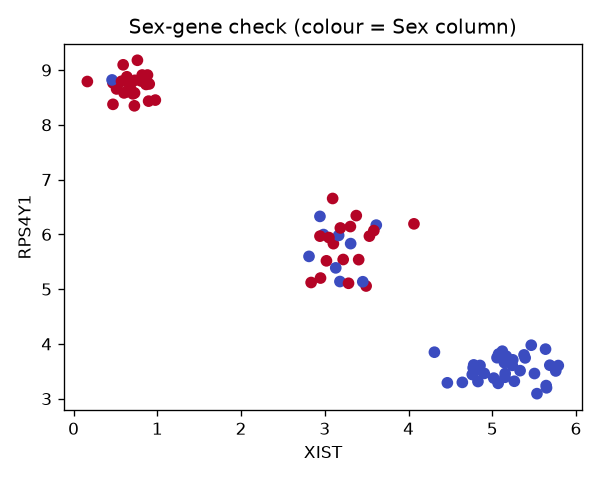

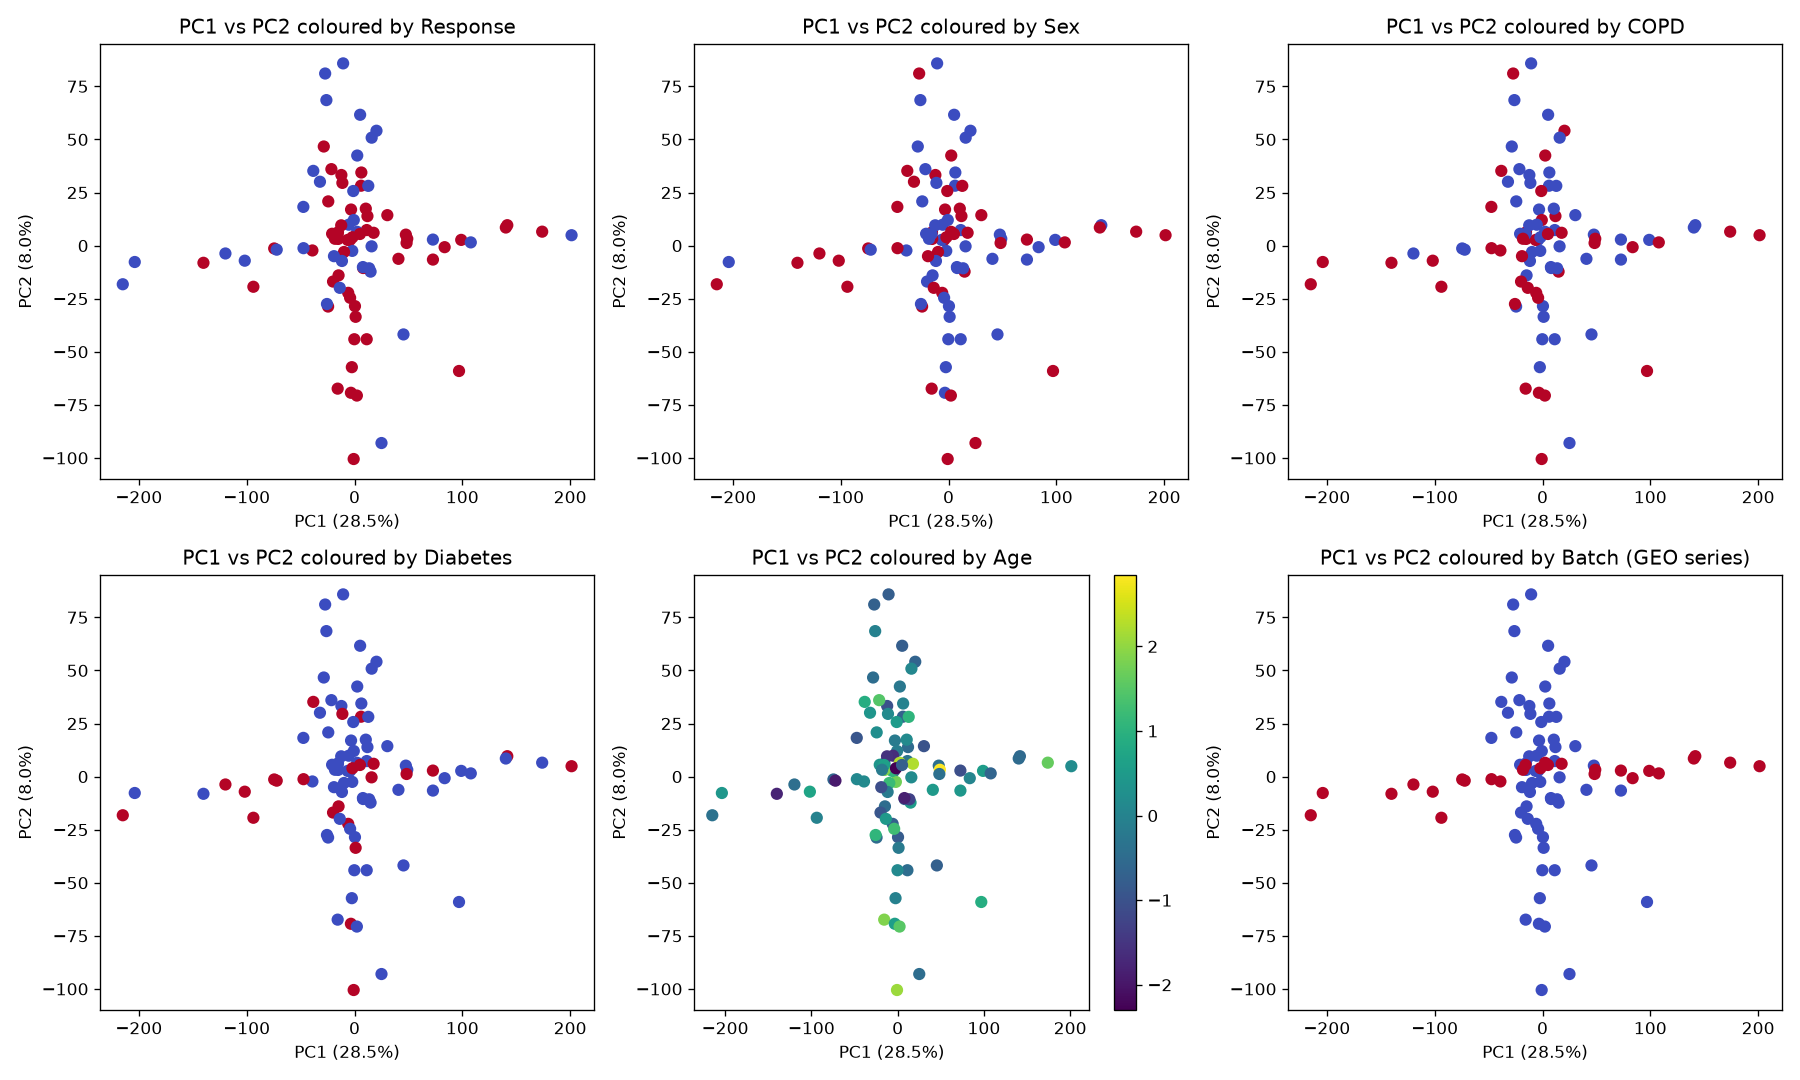

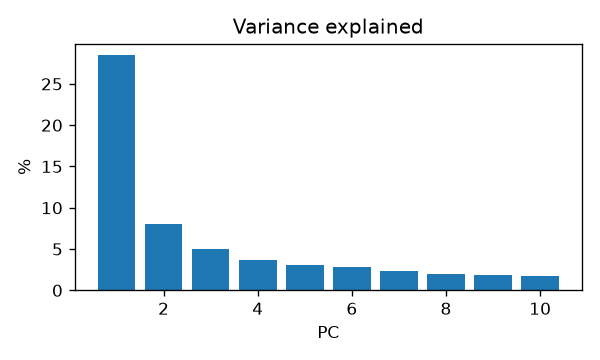

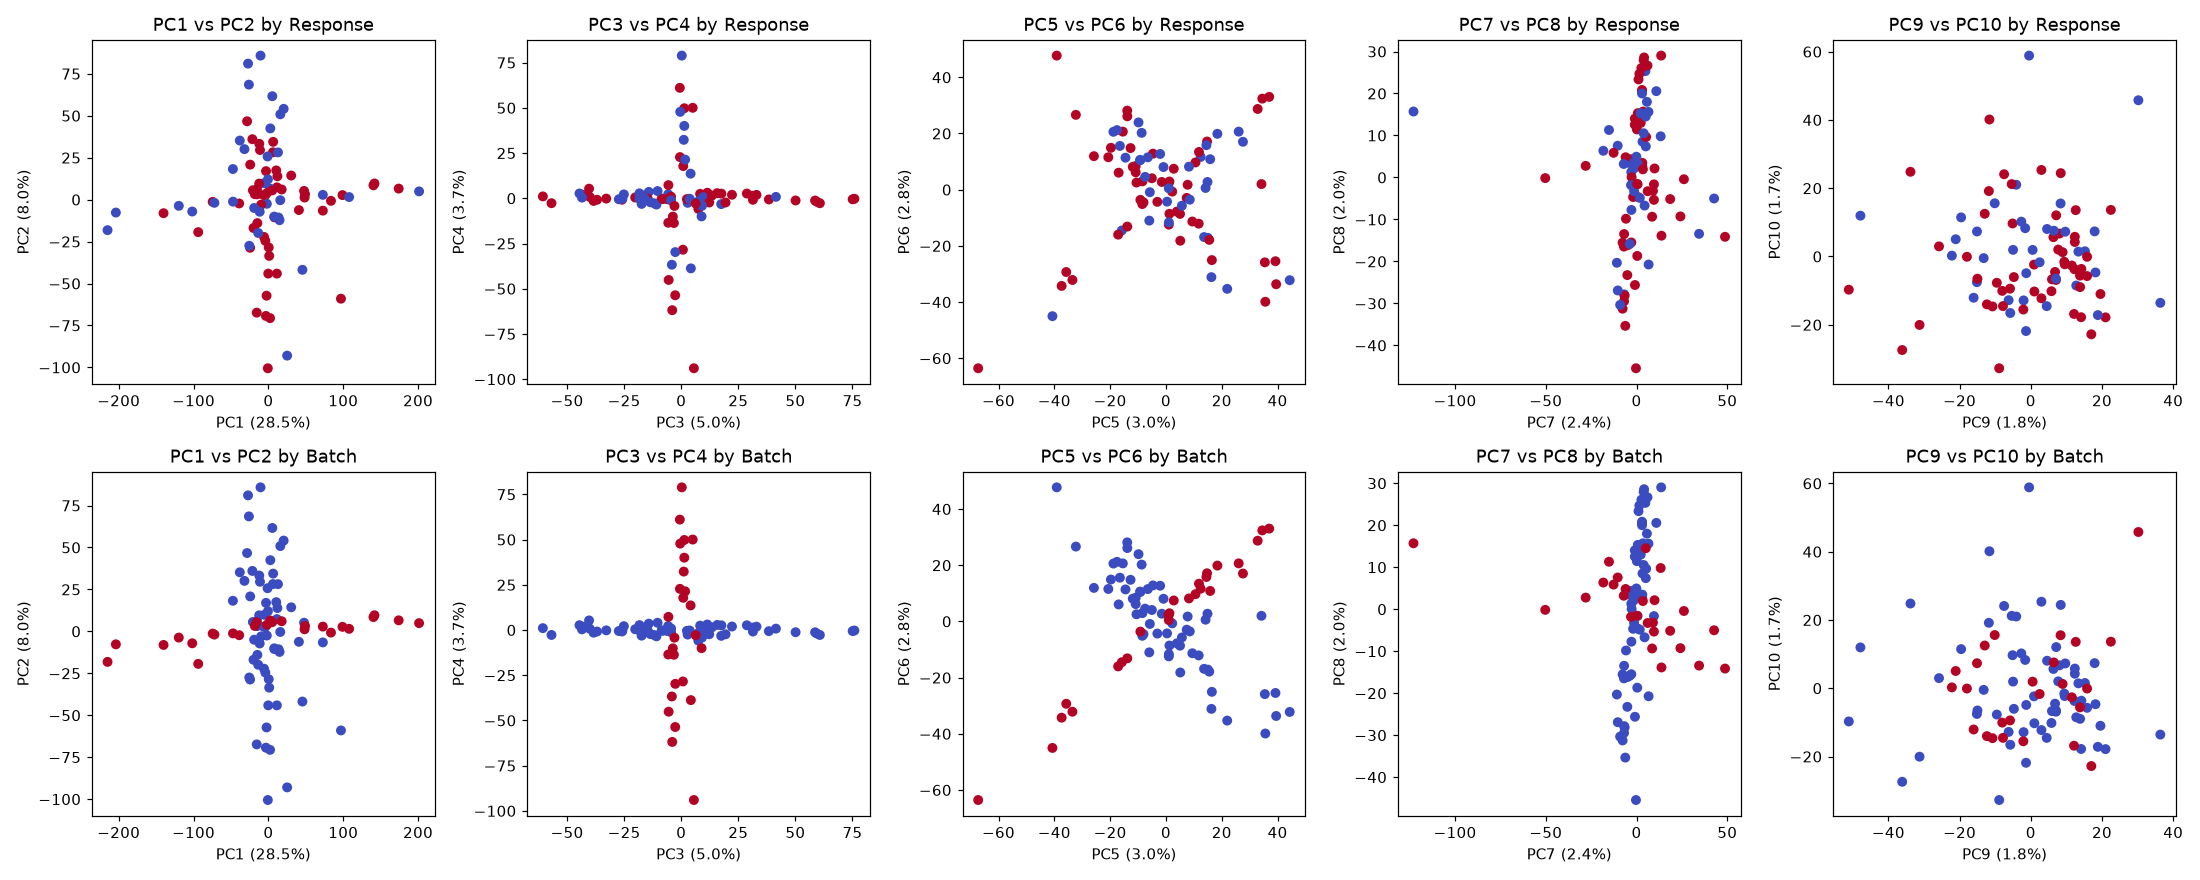

In [3]:
from IPython.display import Image, display
for f in ['results/step02_distributions.png','results/step02_sexcheck.png','results/step02_pca.png','results/step02_pca_variance.png','results/step02_pca_1to10.png']: display(Image(f))

## Step 3 — ComBat batch correction and WGCNA gene modules

**Decision from step 2.** Keep all 89 samples and correct the two array batches (earlier GSM1123, later GSM1616) with ComBat. GSM1123370 stays in, flagged as a probable sex swap.

**What ComBat does.** For every gene it estimates how much each batch shifts the level and how much it stretches the spread, then removes both. The estimates for each gene are shrunk toward the average over all genes (empirical Bayes), which matters when a batch has only 26 samples: a single gene's variance estimate from 26 arrays is noisy, and shrinkage borrows strength from the other 13,514 genes. No biological covariates are passed, so the response label is never used. Implemented in `combat.py` (parametric version of Johnson et al. 2007, same algorithm as sva::ComBat), with a self-check on a planted batch effect.

**What it changes here.** The table arrived with per-batch gene means already identical, so the shift part is a no-op. The later batch is about 1.8 times noisier per gene than the earlier one; ComBat equalises that. Without it, WGCNA correlations and every model would be driven about twice as hard by the 26 noisy arrays as by the 63 clean ones.

**What we do.** Weighted Correlation Network Analysis on the 5,000 most variable ComBat-corrected genes:
1. Signed correlation similarity, raised to a soft-threshold power beta so weak correlations vanish and strong ones stay. We use beta = 12, the WGCNA recommendation for signed networks with more than 40 samples.
2. Topological overlap: two genes are close if they share the same neighbours, not only if they correlate directly. This is more robust to noise than raw correlation.
3. Average-linkage clustering of the overlap dissimilarity, cut recursively (the idea behind dynamicTreeCut) so modules fall between 30 and about 500 genes. Genes that do not fit any module go to module 0 (unassigned).
4. Modules whose eigengenes correlate above 0.75 are merged.
5. Each module is represented by its eigengene: the first principal component of its genes, signed so it moves with the module's average expression. Module membership (kME) per gene ranks hub genes.

The label is never read, so fitting WGCNA on all 89 samples leaks nothing into later steps.

**Why here.** Co-expressed genes are interchangeable to a sparse model, so selecting single genes out of 13,515 is unstable. Modules are the biologically meaningful unit; downstream feature selection runs on eigengenes plus clinical covariates.

**Consequences.** From 13,515 genes to 21 module eigengenes. Everything downstream selects modules, not genes; step 8 goes back inside the selected modules to name genes.

In [4]:
%run step03_wgcna.py

ComBat-corrected 13515 genes across 89 samples; median SD ratio later/earlier batch: raw 1.83 -> corrected 1.02
WGCNA on top 5000 variance genes
soft-threshold power beta=12 (WGCNA default for signed network, n>40); scale-free R^2=0.79, mean connectivity 35.2
smallest beta with R^2>=0.8: 13
modules: 21   unassigned genes (module 0): 2011
module sizes: ME1=31, ME2=42, ME3=317, ME4=38, ME5=31, ME6=38, ME7=113, ME8=294, ME9=270, ME10=229, ME11=352, ME12=70, ME13=37, ME14=40, ME15=55, ME16=59, ME17=41, ME18=135, ME19=273, ME20=424, ME21=100
hub gene per module (highest kME): ME1:TOM1, ME2:DCTN4, ME3:TECPR2, ME4:IGLC1.1, ME5:NPC1L1, ME6:SARDH, ME7:GP1BB, ME8:GMPR, ME9:TMEM214, ME10:FAM96B, ME11:CRX, ME12:NKG7, ME13:RPS11.1, ME14:HERC5, ME15:SKI, ME16:LEF1, ME17:CD19, ME18:STXBP3, ME19:C18orf32, ME20:RCN2, ME21:ALPK1
max |cor(eigengene, batch)| after correction: 0.00


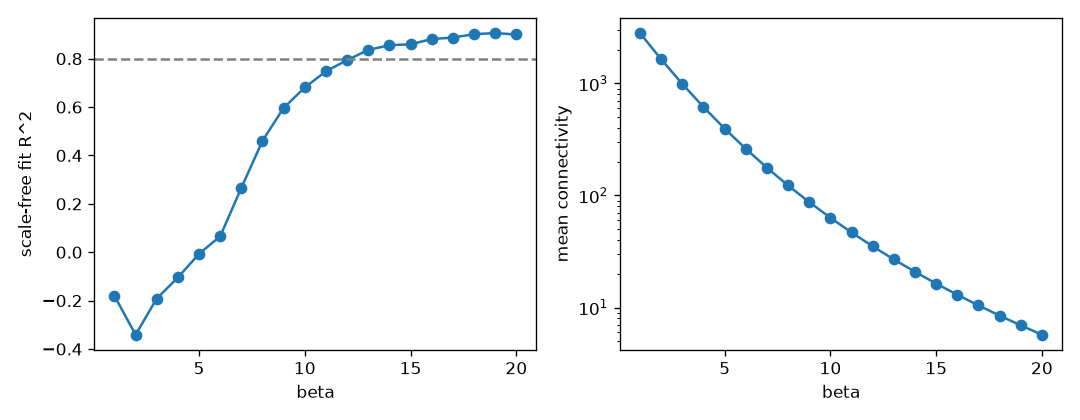

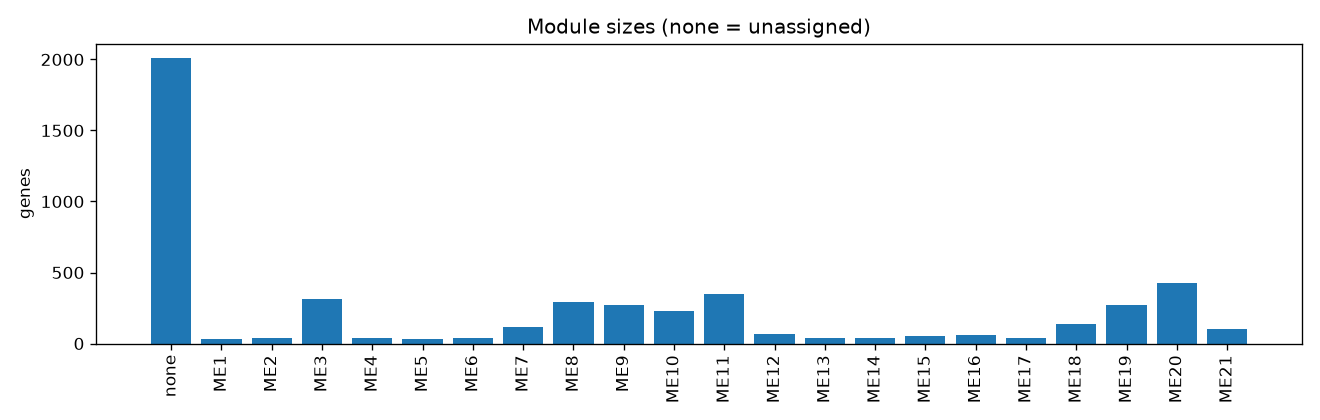

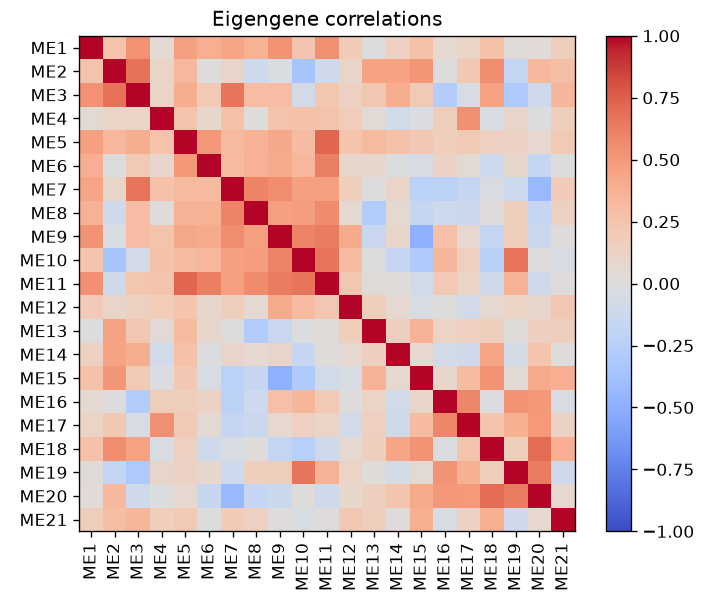

In [5]:
from IPython.display import Image, display
for f in ['results/step03_softthreshold.png','results/step03_module_sizes.png','results/step03_eigengene_cor.png']: display(Image(f))

**Findings.**
- ComBat brought the later/earlier batch spread ratio from 1.83 to 1.02. Eigengene correlation with batch is 0.00.
- 21 modules of 31 to 424 genes; 2,011 of 5,000 genes unassigned. Scale-free fit at beta 12 is 0.79, a proper network this time (the plain scaling run gave 0.55 and 9 coarse modules).
- Several modules are recognisable blood cell-type programmes from their hub genes: ME12 (NKG7, cytotoxic NK/T cells), ME17 (CD19, B cells), ME16 (LEF1, naive T cells), ME4 (IGLC1, immunoglobulin/plasma cells), ME14 (HERC5, interferon response), ME7 (GP1BB, platelets), ME13 (RPS11, ribosomal). That is what a whole-blood or PBMC expression profile should decompose into, which supports the module assignment.
- Consequence: eigengenes for cell-type modules will partly track blood cell composition. A module that predicts response may do so through cell counts rather than gene regulation; step 8 must keep this in mind when interpreting selected modules.

## Step 4 — Hold-out split, pipelines, nested cross-validation, baselines

**Train/test split first.** The expert group revised the step 1 decision: before any supervised step, 18 of the 89 samples (20%, stratified on response and batch, fixed seed) are set aside as a test set (`split.py`, `results/split.csv`). Everything from here to the write-up uses only the 71 training samples. The test set is scored once, at the end, as a final check. Caveat recorded at the checkpoint: an AUC measured on 18 people has a 95% interval about 0.47 wide, so the test set can confirm a large effect but cannot resolve a small one. Cross-validation on the training set remains the working estimate.

ComBat and WGCNA (step 3) stay fitted on all 89 samples. They never read the label, and the module definitions are what let us compute eigengenes for the test samples.

**Cross-validation inside the training set.** The 71 samples are split 5 ways; each fifth is scored by a model trained on the other four, repeated 20 times with different splits. Scaling and the regularisation strength are fitted inside the training part of each fold (a scikit-learn `Pipeline` with an inner cross-validation), so nothing from the scored fifth leaks into training. This is nested cross-validation.

**What we do.** Logistic regression (L2) on three feature sets: clinical only; the 21 WGCNA eigengenes; eigengenes plus clinical. Compared against a chance model that predicts the class prior. Metrics: ROC-AUC (primary), PR-AUC, F1 at 0.5. Spread across the 20 repeats shows how much the score depends on the fold assignment; a bootstrap over samples gives a confidence interval for the main model.

**Why here.** This is the honest floor before any feature selection. If eigengenes cannot beat chance under this scheme, no selection downstream is justified.

In [6]:
%run step04_baselines.py

C:\Users\ReiJiménez\OMISH\step04_baselines.py:50: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  main = pd.DataFrame({r: oofs[f"eigengenes + clinical|{r}"] for r in range(REPEATS)}).mean(1)


TRAIN SET ONLY: 71 samples. 
20 repeats x 5-fold stratified CV, C tuned by inner 5-fold CV (nested). Prevalence 0.606.
AUC 2.5%/97.5% = spread across repeats (how much the score depends on the fold split).
Spec@90%Rec / Prec@90%Rec = specificity and precision at the loosest threshold that still catches 90% of Responders (recall-first operating point).

                       ROC-AUC  PR-AUC  Spec@90%Rec  Prec@90%Rec  AUC 2.5%  AUC 97.5%
model                                                                                
chance                   0.464   0.588        0.000        0.606     0.464      0.464
clinical only            0.432   0.567        0.062        0.608     0.355      0.482
eigengenes only          0.607   0.696        0.157        0.629     0.543      0.682
eigengenes + clinical    0.587   0.684        0.146        0.625     0.491      0.654

bootstrap 95% CI of ROC-AUC, eigengenes + clinical, averaged OOF predictions: 0.407 - 0.691


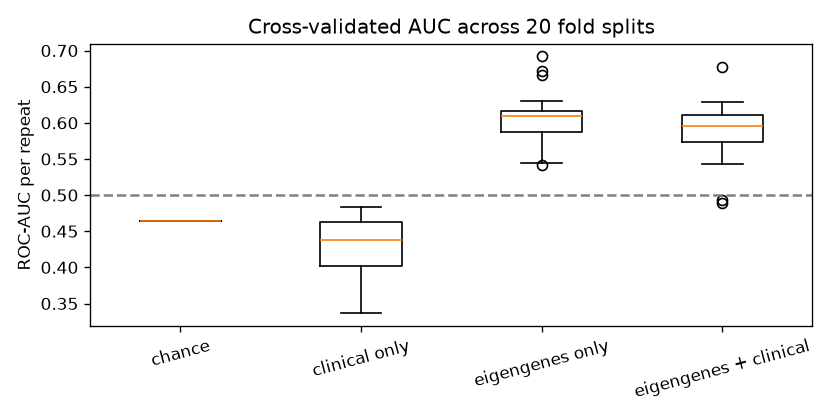

In [7]:
from IPython.display import Image, display
display(Image('results/step04_cv_auc.png'))

**Findings (71 training samples).**

| model | ROC-AUC | PR-AUC | specificity at 90% recall | precision at 90% recall | AUC range across repeats |
|---|---|---|---|---|---|
| chance | 0.46 | 0.59 | 0.00 | 0.61 | |
| clinical only | 0.43 | 0.57 | 0.06 | 0.61 | 0.36 to 0.48 |
| eigengenes only | 0.61 | 0.70 | 0.16 | 0.63 | 0.54 to 0.68 |
| eigengenes + clinical | 0.59 | 0.68 | 0.15 | 0.63 | 0.49 to 0.65 |

Bootstrap 95% CI for eigengenes + clinical: 0.41 to 0.69.

- Clinical variables predict nothing; adding them to the eigengenes makes the model slightly worse, which is what adding four noise features to 71 samples does.
- Eigengenes carry a weak signal: AUC around 0.61, above chance on every one of the 20 splits, never above 0.68.
- **Recall-first operating point (revised step 1 rule).** If the threshold is set so 90% of true Responders are flagged, the eigengene model also flags 84% of Non-responders (specificity 0.16) and the flagged group is 63% Responders against a base rate of 61%. Chance at the same recall has specificity 0. The genes buy 16 points of specificity at fixed recall, no more.
- The bootstrap interval reaches below 0.5. With 71 samples we cannot yet rule out that this signal is noise. The permutation test (step 7) is the proper test.
- F1 at a 0.5 cut is not reported: with 61% Responders it scores a useless model at 0.75 and cannot separate the rows.

**Consequences.** There is something to select for, but it is small, and at the recall the group requires it does not yet translate into a usable screen. Expect stability selection to return few modules. Any AUC is provisional until the permutation test.

## Step 5 — Regularisation types and model families

**What we do.** Same training set, same nested cross-validation as step 4, five models on the 21 eigengenes plus 4 clinical variables:
- **L2 ridge**: shrinks every coefficient, drops none. Step 4's model, repeated here as the reference.
- **L1 lasso**: pushes weak coefficients to exactly zero, so it selects features. Also the engine of stability selection in step 6.
- **Elastic net**: half L1, half L2. Handles correlated eigengenes better than pure L1, which picks one of two correlated modules at random.
- **ANOVA filter + L2**: keep the k modules most associated with response on their own (k tuned), then ridge. Simplest to explain.
- **XGBoost**: gradient-boosted trees, regularised by depth, leaf penalty and minimum leaf size. A different model family, able to see interactions and non-linear effects if they exist.

For the three sparse models we also record how often each feature survives across the 50 outer-fold fits. That is a preview of stability selection.

**Why here.** With 25 features and 71 samples, the choice of regularisation is the main modelling decision. Comparing on identical folds shows whether sparsity helps (a few strong modules) or hurts (many weak ones).

In [8]:
%run step05_models.py

TRAIN SET ONLY: 71 samples. 10 repeats x 5-fold outer CV, hyperparameters by inner 5-fold CV.

                   ROC-AUC  PR-AUC  Spec@90%Rec  Prec@90%Rec  AUC 2.5%  AUC 97.5%
model                                                                            
L2 ridge             0.605   0.698        0.154        0.627     0.546      0.667
L1 lasso             0.534   0.637        0.132        0.622     0.450      0.583
elastic net          0.560   0.661        0.161        0.632     0.452      0.616
ANOVA filter + L2    0.608   0.704        0.186        0.635     0.541      0.660
XGBoost              0.586   0.675        0.121        0.623     0.516      0.625

Fraction of the 50 outer-fold models in which each feature was kept (sparse models only), top 10 by lasso:
      L1 lasso  elastic net  ANOVA filter + L2
ME6       0.78         0.84               0.66
ME9       0.66         0.88               0.90
ME8       0.66         0.60               0.48
ME15      0.64         0.58        

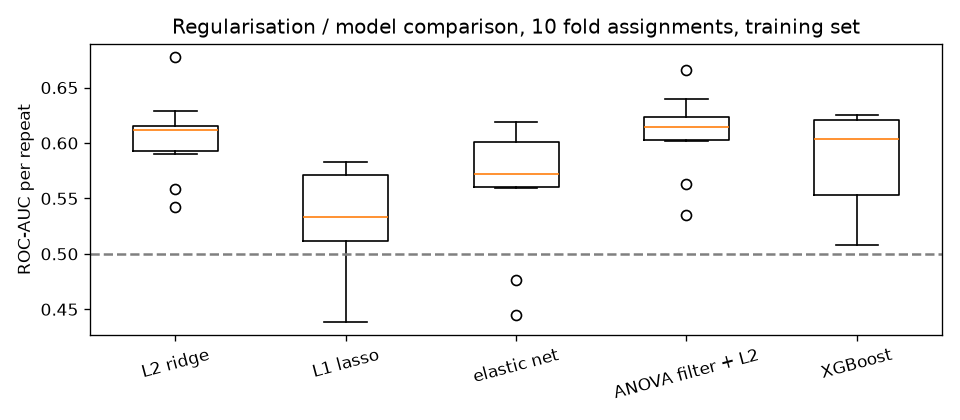

In [9]:
from IPython.display import Image, display
display(Image('results/step05_cv_auc.png'))

**Findings.**

| model | ROC-AUC | PR-AUC | specificity at 90% recall | precision at 90% recall | AUC range across repeats |
|---|---|---|---|---|---|
| L2 ridge | 0.61 | 0.70 | 0.15 | 0.63 | 0.55 to 0.67 |
| L1 lasso | 0.53 | 0.64 | 0.13 | 0.62 | 0.45 to 0.58 |
| elastic net | 0.56 | 0.66 | 0.16 | 0.63 | 0.45 to 0.62 |
| ANOVA filter + L2 | 0.61 | 0.70 | 0.19 | 0.64 | 0.54 to 0.66 |
| XGBoost | 0.59 | 0.68 | 0.12 | 0.62 | 0.52 to 0.63 |

**Recall-first operating point (revised step 1 rule).** The last two columns answer: if we set the threshold so that 90% of true Responders are flagged, what does it cost? Specificity 0.12 to 0.19 means that 81% to 88% of Non-responders are flagged too. Precision 0.62 to 0.64 against a base rate of 0.61 means the flagged group is barely enriched. At this sample size no model can catch most Responders without also calling nearly everyone a Responder.

- **Sparsity hurts.** Lasso is the worst model and elastic net is second worst. The signal is spread thinly over several modules; forcing the model to pick a few loses it. Ridge, which keeps everything, and the ANOVA filter, which keeps about 5 modules chosen by their individual association, do best.
- **XGBoost adds nothing** over a linear model. No sign of interactions or non-linear effects worth the extra flexibility at n=71.
- **Consistently retained features:** ME6, ME9, ME8, ME15 appear in more than 60% of lasso and elastic-net fits; ME9 in 90% of ANOVA fits. COPD is kept by lasso half the time but is nearly never chosen by the filter, so its lasso appearances are noise.
- All AUC ranges still touch or approach 0.5 at the low end. Nothing here is conclusive without the permutation test.

**Consequences.** The working model going forward is ridge or filter + ridge, not lasso. Under the recall-first rule the filter + ridge is marginally the best operating point, but none is usable as a screening test yet. For stability selection (step 6) this means using a mild L1 penalty, or ranking by frequency in the ANOVA filter, rather than a hard lasso that already showed it cannot hold the signal. Candidate modules to watch: ME6, ME8, ME9, ME15.

## Step 6 — Stability selection

**What we do.** Draw half of the 71 training samples at random (keeping the Responder share), run a feature-selection method, record which features it kept. Repeat 500 times. Each feature ends with a selection frequency between 0 and 1. Two selection engines, because step 5 showed that a hard lasso loses the signal:
- **L1 logistic at a mild penalty** (C = 0.3), keeping about 4 features per subsample.
- **ANOVA filter**, keeping the 5 features most associated with response in that subsample.

**The threshold.** Meinshausen and Bühlmann's bound says that if we keep features with frequency at least π, the expected number of false selections is at most q² / ((2π − 1) p), where q is the average number of features selected per subsample and p = 25 is the number of features. We pick a tolerated number of expected false selections and solve for π. That gives a defensible cut rather than an arbitrary one.

**Error rule (revised, DECISIONS 2026-09-17).** The expert group reversed the step 1 preference: a missed real biomarker now costs more than a fake one — the same logic as cancer screening, where a false positive gets a second look but a false negative loses a real signal. We therefore raise the tolerated expected false selections from 1 to **2**, which lowers π and lets weaker-but-consistent modules qualify. The resulting list is a **sensitivity-first screening list, exploratory, not a confirmed biomarker set.**

**Why here.** A gene module that is selected in 90% of half-samples is a candidate biomarker; one selected in 40% depended on which participants happened to be drawn. At n = 71 this distinction is the whole result.

In [10]:
%run step06_stability.py

TRAIN SET ONLY: 71 samples, 25 features, 500 stratified half-subsamples per engine.
EXPLORATORY, sensitivity-first: lists below tolerate more false positives to avoid missing a real biomarker (cancer-screening logic).

L1 (C=0.3): mean #selected per subsample q=4.1
  E[false selections]<=2: pi>=0.67  ->  none
ANOVA top-5: mean #selected per subsample q=5.0
  E[false selections]<=2: pi>=0.75  ->  ME9 (0.77)

selection frequency, all features:
          L1 (C=0.3)  ANOVA top-5
ME6             0.59         0.58
ME9             0.46         0.77
ME10            0.39         0.53
ME15            0.35         0.40
ME8             0.34         0.46
ME13            0.22         0.15
ME11            0.20         0.60
COPD            0.19         0.06
ME18            0.19         0.23
ME12            0.17         0.17
ME2             0.16         0.16
Diabetes        0.15         0.07
ME17            0.09         0.07
ME4             0.09         0.10
Age             0.09         0.06
ME20      

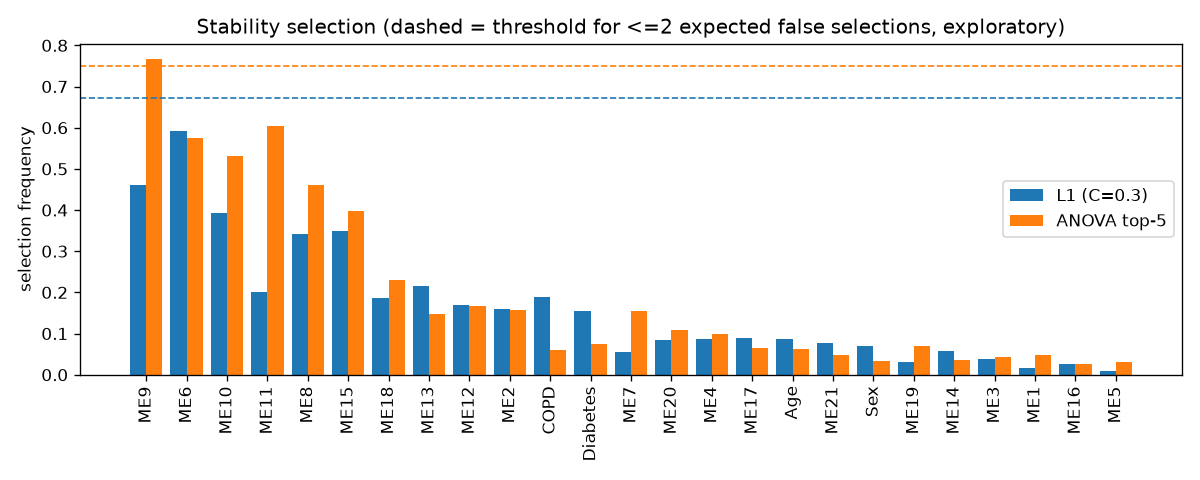

In [11]:
from IPython.display import Image, display
display(Image('results/step06_stability.png'))

**Findings.**

| feature | L1 frequency | ANOVA frequency |
|---|---|---|
| ME9 | 0.46 | 0.77 |
| ME6 | 0.59 | 0.58 |
| ME11 | 0.20 | 0.60 |
| ME10 | 0.39 | 0.53 |
| ME8 | 0.34 | 0.46 |
| ME15 | 0.35 | 0.40 |
| everything else | below 0.25 | below 0.25 |

Under the revised rule (tolerated expected false selections = 2), the thresholds are 0.67 for L1 and 0.75 for the ANOVA filter. **One feature clears it: ME9 (ANOVA, 0.77).** The L1 engine still returns nothing; its most frequent feature (ME6, 0.59) sits below 0.67.

**How to read this.** The ranking is consistent with step 5: ME6, ME9, ME10, ME8, ME15 are the modules the models lean on, and the four clinical variables are never chosen. Relaxing the error budget from 1 to 2 promotes ME9 from "unconfirmed" to the screening list; ME6 remains the closest runner-up. Loosening further to 3 changes nothing (same list), so the thin signal is a property of the cohort, not an artefact of the strict bar.

**Consequences.**
- Under the revised rule (a missed real biomarker costs more than a fake one, cancer-screening logic), the screening result is: **ME9 is the one module that survives at a controlled — but deliberately loosened — false-positive budget, with ME6 as the runner-up worth watching.**
- This is a sensitivity-first, exploratory list, not a confirmed biomarker set. The expected-false-selection budget of 2 means the list is allowed to contain a false positive by design.
- The weak but consistent predictive signal (AUC about 0.6) is real as a whole-profile effect, spread across several modules, and is only partly localised to ME9.
- Step 7 (permutation test) decides whether even the whole-profile signal beats chance. Step 8 describes ME9 and ME6 as leads for a larger cohort, labelled as such.

## Step 7 — Permutation test

**What we do.** Shuffle the Responder labels among the 71 training participants so they no longer match anyone's expression, run the whole supervised pipeline (feature selection inside the folds, model, cross-validated AUC), and record the AUC. Repeat 500 times. This gives the distribution of scores the method produces when there is nothing to find. The p-value is the fraction of shuffles that scored at least as well as the real labels.

Two pipelines, with fixed hyperparameters to keep 500 runs tractable: ridge on all 25 features (C = 1), and ANOVA top-5 filter followed by ridge, the best configuration from step 5.

**Why here.** With 25 features and 71 samples, a pipeline can reach AUC 0.65 on random labels by luck. This test is the only thing in the project that says whether the 0.6 we have been seeing is distinguishable from that luck.

In [12]:
%run step07_permutation.py

TRAIN SET ONLY: 71 samples. 500 label permutations; each scored by 5x5-fold CV (selection inside folds).

ridge, all 25 features: real AUC 0.529; null mean 0.496, 95th percentile 0.634, max 0.796; permutation p = 0.369

ANOVA top-5 + ridge: real AUC 0.622; null mean 0.496, 95th percentile 0.639, max 0.815; permutation p = 0.082


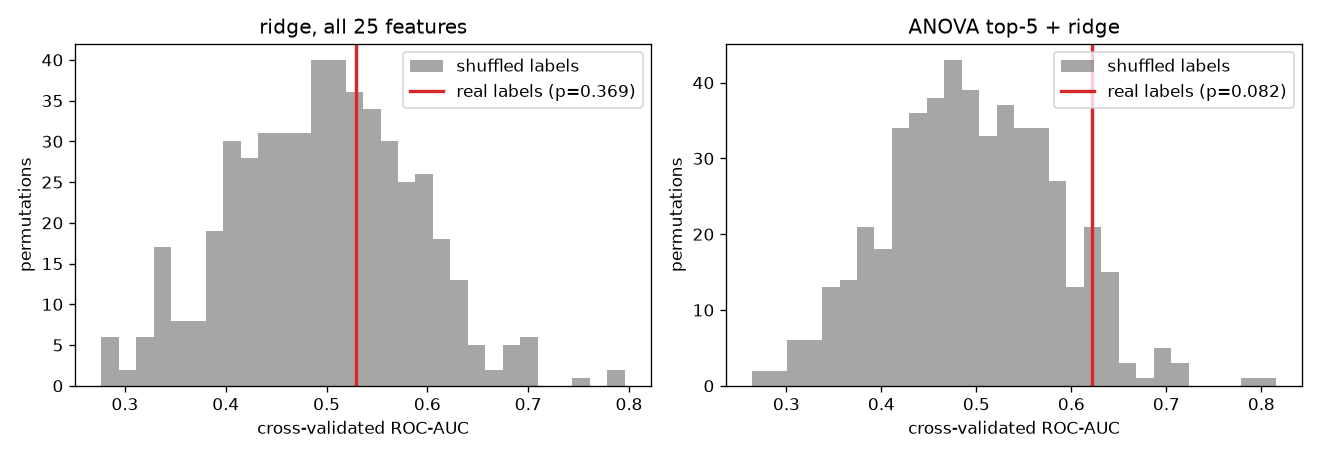

In [13]:
from IPython.display import Image, display
display(Image('results/step07_permutation.png'))

**Findings.**

| pipeline | real AUC | null mean | null 95th percentile | null max | permutation p |
|---|---|---|---|---|---|
| ridge, all 25 features | 0.53 | 0.50 | 0.63 | 0.80 | 0.37 |
| ANOVA top-5 + ridge | 0.62 | 0.50 | 0.64 | 0.82 | 0.08 |

- **Neither pipeline is significant at the conventional 0.05 level.** The filter + ridge pipeline sits just under the 95th percentile of the null: about 1 in 12 random label shufflings score as well as the real labels.
- The null distribution shows what n = 71 can do by chance alone: shuffled labels reach AUC 0.80 in the best of 500 tries and exceed 0.63 in 5% of them. Any single AUC below about 0.65 from this cohort is within the range of luck.
- Ridge with a fixed C = 1 scores lower (0.53) than the tuned ridge of step 4 (0.61), because the inner CV there chose much stronger regularisation. That gap is itself a sign of how sensitive the result is to one setting.

**Consequences.**
- The whole-profile signal is suggestive (p about 0.08) but not established. The project cannot claim that baseline gene expression predicts response in this cohort.
- Combined with step 6 (no stable module), the defensible conclusion is: no confirmed biomarker; ME6 and ME9 are unconfirmed leads worth testing in a larger cohort.
- Steps 8 to 10 (inside the modules, SHAP, biology) still have value as a description of the leads, provided every statement is labelled as descriptive, not confirmatory. The 18-sample test set will be scored in step 11 as the last check, with the caveat that at n = 18 it can only confirm a large effect.

## Step 8 — Inside the lead modules (descriptive)

**Status.** ME9 is the one module on the screening list (step 6, budget of 2 expected false selections); ME6 is the runner-up. The whole-profile signal did not pass the permutation test (step 7, p about 0.08). Everything in this step is therefore a description of leads, on the 71 training samples, not a confirmation.

**What we do.** For every gene, on the ComBat-corrected data: log fold change Responders minus Non-responders (the arrays are log-scale, so a difference of means is a log fold change); a moderated t-test in the limma style, where each gene's variance is shrunk toward the variance typical of all genes, which is the standard way to get stable per-gene tests from small groups; Benjamini-Hochberg false discovery rate over all 13,515 genes and, separately, within each module. For each lead module: the eigengene difference between groups and its AUC, the share of member genes higher in Responders, the hub genes (highest module membership kME), and the most differential genes.

**Why here.** The model worked on module scores. Biologists need to see the genes, their direction, and effect sizes in familiar units to judge whether the module is a plausible programme or an artefact. A module whose members all shift the same way is a coherent signal even when no single gene survives multiple-testing correction.

In [14]:
%run step08_modules.py

TRAIN SET ONLY: 71 samples. Moderated t-test prior df d0=9.4 (larger = more shrinkage toward a common variance).
genes with FDR<0.05 across all 13515 genes: 0; FDR<0.25: 7

ME9: 270 genes. Eigengene Responders - Non_responders = +0.67 SD units, AUC 0.68, Mann-Whitney p=0.010
  genes with p<0.05 (unadjusted): 133 of 270 (expected by chance ~14); FDR<0.25 within module: 210
  direction: 98% of genes higher in Responders
  top hub genes (kME): TMEM214 (kME 0.91, logFC +0.19, p 0.006), PRKCSH (kME 0.90, logFC +0.21, p 0.008), SLC4A2 (kME 0.89, logFC +0.14, p 0.038), DCAF15 (kME 0.88, logFC +0.08, p 0.211), DCTN1.2 (kME 0.87, logFC +0.20, p 0.019), FLNA (kME 0.87, logFC +0.19, p 0.012), PNPLA6 (kME 0.87, logFC +0.15, p 0.060), HECTD3 (kME 0.87, logFC +0.26, p 0.002)
  most differential genes (|t|): DHCR24 (logFC +0.32, p 0.0000), SFXN3 (logFC +0.25, p 0.0001), SLC9A3R1 (logFC +0.28, p 0.0002), MICU1 (logFC +0.35, p 0.0002), MAP4K1 (logFC +0.25, p 0.0002), NADSYN1 (logFC +0.21, p 0.0006), SE

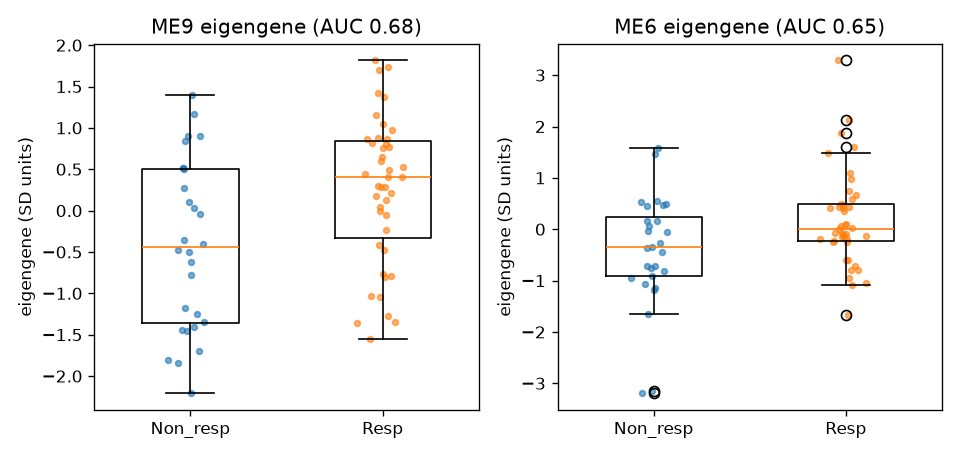

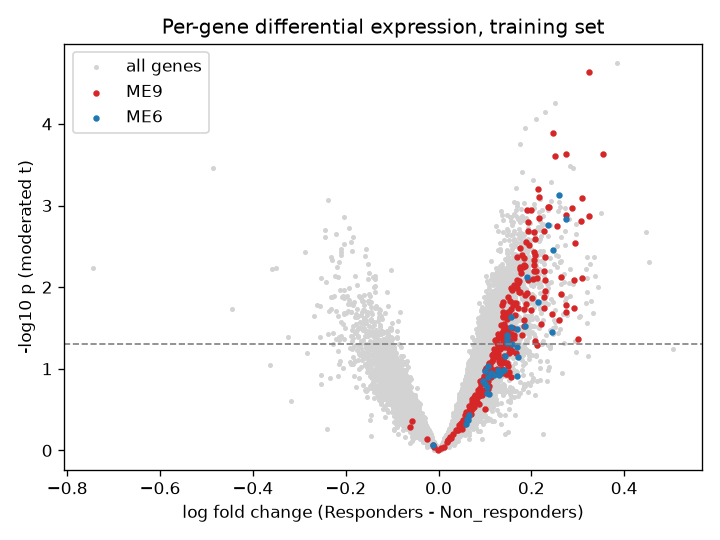

In [15]:
from IPython.display import Image, display
for f in ['results/step08_eigengenes.png','results/step08_volcano.png']: display(Image(f))

**Findings.**

| | ME9 | ME6 |
|---|---|---|
| genes | 270 | 38 |
| eigengene shift, Responders minus Non-responders | +0.67 SD | +0.60 SD |
| eigengene AUC | 0.68 | 0.65 |
| Mann-Whitney p | 0.010 | 0.038 |
| member genes higher in Responders | 98% | 97% |
| genes with unadjusted p < 0.05 | 133 of 270 (about 14 expected by chance) | 14 of 38 (about 2 expected) |

- **Across all 13,515 genes, no gene passes FDR 0.05 and 7 pass FDR 0.25.** No single gene is a significant marker on its own. That was expected from steps 6 and 7.
- **Both lead modules shift as a block.** Nearly every member gene is higher at baseline in Responders, and ME9 has ten times more nominally significant genes than chance would give. This is a coherent module-level signal, which is exactly what WGCNA is meant to find and what a single-gene analysis misses.
- The within-module FDR values in the CSVs are optimistic: member genes are correlated by construction, so they are not independent tests. Read them as a ranking, not as error rates.
- **ME9 hub genes:** TMEM214, PRKCSH, SLC4A2, DCTN1, FLNA, HECTD3. **Most differential:** DHCR24 (cholesterol biosynthesis), SFXN3, SLC9A3R1, MICU1 (mitochondrial calcium uptake), MAP4K1, NADSYN1, GPI (glycolysis). Several of these are metabolic, which is at least consistent with a weight-loss phenotype; the experts should judge.
- **ME6 hub genes:** SARDH, ST8SIA5, POSTN, DENND2A, CACNG2. **Most differential:** CDH9, KREMEN2, CELSR3-AS1, CYB5R1. A small module with several neural-type genes, unusual in blood; worth checking whether it is a platform or probe artefact before investing in it.
- Effect sizes are small: log fold changes of 0.2 to 0.35 on a log2-like scale, about 15% to 25% higher expression in Responders.

**Consequences.** ME9 is a coherent, small, metabolic-leaning baseline shift toward higher expression in future Responders. It is the single lead this cohort supports, under a deliberately loosened error budget. Step 10 (enrichment, comparison with the MEvA-X paper) can say whether the gene set is biologically meaningful. Nothing here changes the statistical position: descriptive, n = 71, no confirmation.

## Step 9 — Interpretation: coefficients, enrichment, comparison with MEvA-X

**SHAP dropped.** The working model is ridge logistic regression on 25 standardised features. For such a model a SHAP value is the coefficient times the feature's deviation from its mean, so the coefficients are the full explanation. XGBoost, the model SHAP is designed for, added nothing in step 5. Decision logged.

**What we do.**
1. **Coefficients.** Ridge (C = 0.1, in the range the inner cross-validation chose) on eigengenes plus clinical, 71 training samples, standardised features, so each coefficient is the change in log-odds of Responder per one standard deviation of the feature. Bootstrap over samples (1,000 draws) for 95% intervals and for the probability that each coefficient is positive.
2. **Enrichment.** Over-representation of ME9 and ME6 members in Hallmark, GO Biological Process, KEGG and Reactome gene sets via Enrichr, with the 5,000 genes WGCNA saw as the background. Using the whole genome as background would inflate every blood-expressed term.
3. **Comparison with the source paper.** The MEvA-X paper (Bioinformatics 2023) reports a 9-gene Ornish model with hubs AP2B1, RAC3 and TMEM33, plus LINC00588 and BIK, AUC above 0.75 under 10-fold cross-validation with no hold-out set. We locate those genes in our module map.

In [16]:
%run step09_interpret.py

TRAIN SET ONLY: 71 samples.

Ridge (C=0.1) coefficients per SD of feature, log-odds of Responder; 95% bootstrap interval; P(coef>0):
      coef    lo    hi  P(coef>0)
ME6   0.27 -0.01  0.49       0.97
COPD -0.20 -0.48  0.09       0.11
ME9   0.19 -0.02  0.36       0.96
ME8   0.19 -0.06  0.42       0.94
ME15 -0.17 -0.38  0.09       0.10
ME17  0.17 -0.09  0.36       0.90
ME3  -0.14 -0.29  0.06       0.06
ME13 -0.14 -0.37  0.12       0.16
ME12  0.13 -0.15  0.41       0.83
ME18 -0.12 -0.29  0.04       0.06
features whose interval excludes 0: none

ME9 (268 genes) enrichment vs 5000-gene background; terms with adjusted p<0.1: 2
     Gene_set                                                  Term                       Genes  Adjusted P-value
Reactome_2022              Other Interleukin Signaling R-HSA-449836 IL32;CSF1R;CD4;STXBP2;VAMP2          0.046922
Reactome_2022 Generation Of Second Messenger Molecules R-HSA-202433   ZAP70;CD4;PKN1;CD3E;CD101          0.067678

ME6 (38 genes) enrichment v


MEvA-X paper genes (named in the paper) located in our module map:
  AP2B1: AP2B1 -> module ME8
  RAC3: RAC3 -> module not in top-5000 variance
  TMEM33: TMEM33 -> module unassigned
  LINC00588: LINC00588 -> module not in top-5000 variance
  BIK: BIK -> module unassigned


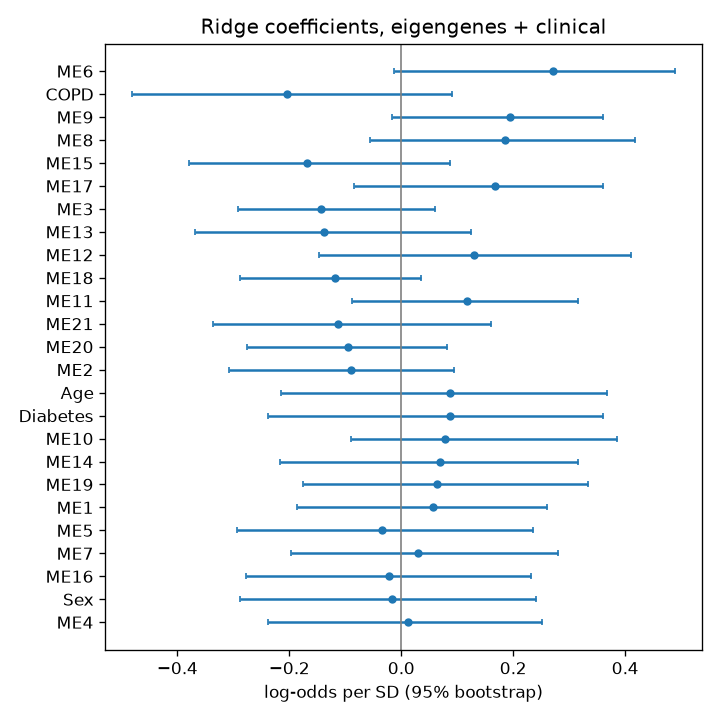

In [17]:
from IPython.display import Image, display
display(Image('results/step09_coefficients.png'))

**Findings.**

*Coefficients (log-odds of Responder per SD; 95% bootstrap interval; probability the sign is positive).*

| feature | coef | interval | P(positive) |
|---|---|---|---|
| ME6 | +0.27 | -0.01 to +0.49 | 0.97 |
| COPD | -0.20 | -0.48 to +0.09 | 0.11 |
| ME9 | +0.19 | -0.02 to +0.36 | 0.96 |
| ME8 | +0.19 | -0.06 to +0.42 | 0.94 |
| ME15 | -0.17 | -0.38 to +0.09 | 0.10 |
| ME17 | +0.17 | -0.09 to +0.36 | 0.90 |

No interval excludes zero. ME6 and ME9 are the two features whose sign is stable in more than 95% of bootstrap draws, consistent with step 8. Effects are small: one SD of ME6 shifts the odds of responding by about 30%.

*Enrichment (adjusted p < 0.1, background = 5,000 WGCNA genes).*
- **ME9** (268 genes): two Reactome terms, "Other interleukin signaling" (IL32, CSF1R, CD4, STXBP2, VAMP2) and "Generation of second messenger molecules" (ZAP70, CD4, PKN1, CD3E, CD101). Both are T-cell signalling terms driven by CD4, CD3E, ZAP70. Together with the metabolic genes from step 8 (DHCR24, GPI, MICU1), ME9 looks like a mixed module: part T-cell activation state, part cellular metabolism. A higher ME9 at baseline in future Responders could reflect more or more active CD4 T cells in blood.
- **ME6** (38 genes): cadherin-mediated cell adhesion (CDH9, CDH12), bicarbonate transport (CYB5R1, SLC4A3). Cadherins 9 and 12 are neural adhesion molecules, not expected in blood. Combined with the small module size, this points to a probe or platform artefact rather than biology. We recommend not investing in ME6.

*MEvA-X comparison.* Of the five paper genes we could name: AP2B1 sits in our ME8 (a module that ranked fourth in stability); TMEM33 and BIK are in the WGCNA input but were not assigned to any module; RAC3 and LINC00588 did not make the top-5,000 variance filter. **No overlap with ME9 or ME6.** Two analyses on the same 89 samples, one selecting single genes with an evolutionary search and 10-fold CV without a hold-out, the other selecting co-expression modules under stability and permutation control, agree on almost nothing. The paper's AUC above 0.75 is inside the range our permutation null reaches on shuffled labels (95th percentile 0.64, maximum 0.82), which is the expected outcome when a flexible search is scored by cross-validation alone at n = 89.

**Consequences.** ME9 is a plausible, weak, T-cell and metabolism related baseline signal and remains the single lead. ME6 should be treated as a likely artefact. The disagreement with MEvA-X is itself a finding: it argues that this cohort is too small for any method to name genes reliably, and that the published 9-gene set needs the same scrutiny.

## Step 10 — Test set, scored once, and conclusions

**What we do.** The 18 participants set aside in step 4 have not been read by any step since. Models are fitted on the 71 training participants with hyperparameters fixed in advance (from steps 4 and 5) and the 90%-recall threshold fixed on training out-of-fold predictions. Each is then scored on the 18 exactly once. Three scorers: the best cross-validated pipeline (ANOVA top-5 + ridge), ridge on all 25 features, and the ME9 eigengene by itself.

**Why here.** This is the only number in the project computed on data that influenced no decision. With 18 participants it can confirm a large effect and nothing smaller; the bootstrap intervals show that limit.

In [ ]:
%run step10_final.py

In [ ]:
from IPython.display import Image, display
display(Image('results/step10_test.png'))

**Findings.**

| model | test ROC-AUC | bootstrap 95% | PR-AUC (chance 0.61) | sensitivity | specificity |
|---|---|---|---|---|---|
| ANOVA top-5 + ridge | 0.51 | 0.23 to 0.78 | 0.70 | 9/11 | 0/7 |
| ridge, all 25 features | 0.52 | 0.24 to 0.79 | 0.73 | 9/11 | 0/7 |
| ME9 eigengene alone | 0.43 | 0.16 to 0.72 | 0.61 | 9/11 | 0/7 |

The models score at chance on the held-out participants, the lead module below it, and at the recall-first threshold every Non-responder is flagged.

## Conclusions

1. **No confirmed biomarker.** Test set at chance; training permutation p about 0.08; no gene passes FDR 0.05 among 13,515. Every line of evidence agrees.
2. **The weak training signal (CV AUC 0.61) did not transfer.** It was consistent across fold assignments but inside the range shuffled labels reach, and it does nothing as a screen at 90% recall.
3. **ME9 is a hypothesis for a larger cohort, not a result.** 270 genes, coherently higher at baseline in future Responders in the training data, T-cell signalling plus metabolic members; cleared stability selection only under the loosened budget; did not generalise to 18 new people.
4. **ME6 is a likely artefact** (neural cadherins in blood, 38 genes).
5. **The MEvA-X 9-gene set is not reproduced**, and its reported AUC lies within our permutation null.

**Why "not established" rather than "no".** An effect of AUC 0.6 to 0.65 cannot be separated from noise at n = 71. Roughly 300 to 400 participants, or an independent cohort of this size testing ME9 directly, would be needed. The GEO series' 3-month and 1-year arrays and control arm could answer a cheaper question: does ME9 change with weight loss.

**Data quality to pass on.** Two array batches differing 1.8-fold in spread, mean-aligned upstream, ComBat applied; sex genes uninformative in the 26-sample batch; GSM1123370 a probable sex swap.

Full text in `REPORT.md`. Every decision and its reason in `DECISIONS.md`.